# Getting started with Gaslab

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from IPython.display import display

from gaslab import GasState
from gaslab.plotting import mollier_figure


© Tim Colonius, California Institute of Technology

Revised: July 11, 2023

What is Gaslab?

Gaslab facilitates doing gasdynamic calculations for perfect gases, replacing old-fashioned tables, charts, and obviating the need to do tedious algebra.  Functionality include standard steady 1D gasdynamics processes including quasi-1D isentropic flow with area change, frictional flow in a constant area duct (Fanno), heat transfer in a constant area duct (Rayleigh) and normal shock waves.  It also includes routines for oblique shocks and Prandtl-meyer expansions that can be used to solve certain 2D steady supersonic flow problems.

States

Gaslab defines a state corresponding to steady unidirectional flow at some point (or station).  There are two modes for defining states: dimensional and dimensionless.  In either mode, the state requires the user to input a Mach numbrer, $M$, and a ratio of specific heats, $\gamma$, for the specific gas in question.  In dimensional mode, the user must also specify the pressure p, and temperature, $T$, and the molecular weight, MW, of the gas.  Note that either 2 or 5 arguments are required (never any other number). The syntax is documented in the help.



Example: specify air at a Mach number of 2 in dimensionless mode

In [2]:
s_dimless = GasState.init(2, 1.4)

Example: specify acetylene at a Mach number of  0.5, pressure of 5 atm, and a temperature of 800K.

In [3]:
s_dim = GasState.init(0.5, 1.3, 5, 800, 26.04)

Note that in many problems, the data required to initialize the state may not be know--it must be determined by solving some equations involving the state rather than simply specifying it.  One can use a function handle and root finding to deal with this situation, so it is good to learn the syntax:

In [4]:
funhand = lambda mach: GasState.init(mach, 1.4)


This defines a function that initializes the state for a perfect gas with $\gamma
=1.4$, for example

In [5]:
s_dimless2 = funhand(2)

creates the same state as s_dimless above.

Getting specific properties of a state

Gaslab defines funtions that return pertinent information regarding the state, such as the Mach number, pressure, temperature, and so on.  The form of the output is determined by the mode in which the gaslab state is initialized (dimensional or dimensionless).  The functions are documented in the help and further example are given below.  The syntax is 

state.prop


In [6]:
print(s_dimless2.mach)

2




Forward example: Consider an airflow at Mach 0.5 with pressure and temperature of 5 atm and 800 K, respectively.  What is the stagnation pressure?

In [7]:
GasState.init(0.5, 1.4, 5, 800, 28.96).stagpres


5.931063190221991

Inverse example: Consider an airflow with a 800 K with pressure and temperature of 5 atm and 800 K, respectively.  If the stagnation pressure is 5.9311 atm, what is the Mach number?

In [8]:
zerofun = lambda mach: 5.9311 - GasState.init(mach, 1.4, 5, 800, 28.96).stagpres
root_scalar(zerofun, bracket=[0, 5], method="brentq").root  # should return 0.5


0.5000093092973147

Above are two examples of properties (mach and stagpres).  These are special cases of a more general command `querystate', that returns whatever (available) properties of the state you want.  For example

The full list of available properties can be found in the help

Example: Consider an airflow with a 800 K with pressure and temperature of 1 atm and 300 K, respectively.  Verify that the Gaslab state satisfies the perfect gas law

In [9]:
s1 = GasState.init(0.5, 1.4, 1, 300, 28.96)
rgas = 8314 / 28.96

print(101325 * s1.pres / (s1.density * s1.temp * rgas)) # should be unity if perfect gas
# note the conversion from atm to Pa

# note that an easier solution uses nondimensional form:
s1 = GasState.init(0.5, 1.4)
print(s1.pres / (s1.density * s1.temp))  # should be unity if perfect gas


1.0
1.0


Processes

Gaslab comes equipped with 5 builtin processes that return a new state given an old state and some required/optional parameters that specify the process.  The processes and parameters to specify them are documented in the help.

Problem 1: Air at Mach 2 is expanded in a diverging section (supersonic nozzle) whose inlet-to-outlet area ratio is 0.2.  At the outlet, what are the Mach number and ratio of temperature to inlet stagnation temperature?

In [10]:
s_out = GasState.init(2, 1.4).areachg(1/0.2)
print(s_out.mach)
print(s_out.temp)


3.735289529332424
0.26381899921212154


Note that we used nondimensional form of initialization, and the area-ratio used in areachg is defined to be the area of the output state relative to the input state (which is 1 over the inlet-to-outlet area in this case).

Problem 2: For the nozzle of problem 1, if the pressure and temperature of the inlet stream are 1 atm and 300K, respectively, find the speed of the stream at the outlet.

There are a couple of ways to proceed.  Since we have the initial stagnation conditions, we can invoke gaslab in dimensional mode

In [11]:
u_out = GasState.init(2, 1.4, 1, 300, 28.96).areachg(1/0.2).speed
print(u_out)

893.8073749555228


Note that the value is output in m/s.   We could also ask for the speed based on the nomdimensional initialization from problem 1

In [12]:
u_out_nondim = s_out.speed  # relative to a0i!
print(u_out_nondim)

1.91856847778217


To get the speed in units of m/s, we would have to remember (see help gaslab) that in nondimensional mode, sound speed is output relative to the stagnation sound speed of the initilized state (a_0i).  We can check that this is correct.  For air at 500k and M=2, we would need to compute the stagnation sound speed the stagnation temperature

 $a_{0i}  = \sqrt{ \gamma R T_{0i}}$ 

or

In [13]:
a0i= np.sqrt(1.4 * GasState.init(2, 1.4, 1, 300, 28.96).stagtemp * (8314/28.96))
u_out_2 = a0i * u_out_nondim
print(u_out_2)


893.8073749555227


which agrees with what we got above.

Composite processes

We can concatenate processes to generate composite processes.  

Problem 3: Suppose that we add a duct with friction to the outlet of the diverging nozzle in example 1.  The duct friction factor is specified to be 0.1.  At the end of the duct, we have a normal shock.  Create a composite gaslab process for this scenario.

In [14]:
result = GasState.init(2, 1.4).areachg(1/0.2).fanno(0.1).normalshock()


We obtain a state that is the net result of the 3 processes, and we can query the state in the usual ways:

In [15]:
print(result.mach)  # mach number of result
print(result.pres) # pressure of result relative to stagnation pressure of the initialized stream


0.4799182860412217
0.13973203538116327


It is important to remember that, in non-dimensional mode, Gaslab normalizes quantities with reference to the initialized state.

Composite processes remember their histories. Gaslab allows you to view information regarding all the intermediate states obtained in a composite process.  Recall that the state 'result' from Problem 3 arose from a composite process involving 4 states.  The command

In [16]:
[st.mach for st in result]


[2, 3.735289529332424, 2.922802490530918, 0.4799182860412217]

produces a 4 x 1 array with the Mach number for each of the 4 states reached in the history of the state 'result'.  The command

In [17]:
[[st.pres, st.temp] for st in result]


[[0.12780452546295096, 0.5555555555555556],
 [0.00943129305738079, 0.26381899921212154],
 [0.014258511410733987, 0.36920056797941203],
 [0.13973203538116327, 0.9559641680576669]]

produces a 4 x 2 array with a row for each state in the composite process and a column for each property queried (pressure and temperature in this case).

Visualizing composite processes with Mollier diagrams

In gasdynamics, it is traditional (and insightful) to plot these processes in the enthalphy-entropy space.  In a perfect gas, this is equivalent to temperature-entropy, and they are also often called "T-s diagrams".  Considering the composite process in Problem 3, we can call

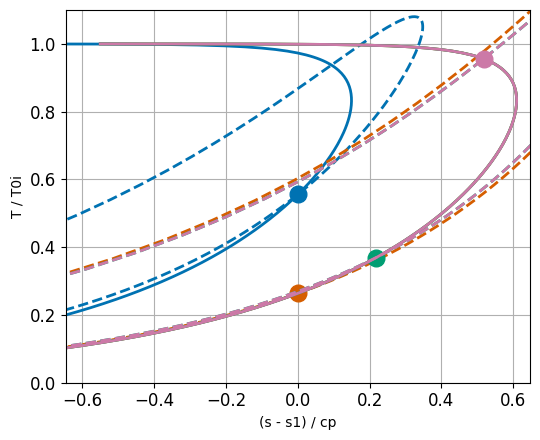

In [18]:
fig = mollier_figure(result)
fig


The solid lines are called "Fanno lines", and represent all the states that can be reached from a given state (labeled as 1-4 on the diagram) through a frictional but adiabatic process. The dashed lines are "Rayleigh lines" and are states reachable through heat transfer in the absence of friction.  Moreover, any normal shock must connect points that are on the same Rayleigh and Fanno lines, and this can be see in the 

In problem 3, since state 2 was reached through isentropic area change, it lies on the same isentrope (0) as state 1.  moreover, we go from state 2 to state 3 in a frictional process, thus states 2 and 3 share Fanno lines.  Foinally, we see that the states 3 and 4 share the same Rayliegh and Fanno lines, with state 3 on the lower branch (supersonic flow) and state 4 on the upper branch (supsonic flow).  Note that in the diagram, the dark blue lines corresponding to Rayleigh and Fanno lines for state 3 are not visible since the cyan lines for state 4 are directly on top of them.

There are optional arguments to `histtab' and 'mollier' that control the labels and colors for the different states.  

More on processes/queries as function handles

It is often useful to pose inverse problems, such as "what nozzle area ratio should I choose to achieve a certain Mach numbrer (or pressure ratio or whatever)".  You can readily solve these inverse problems by defining a process/function query as a function handle.  

For example, suppose that we take example 3, and let the inlet Mach number be a variable rather than a specified quantity.  Suppose also that we are interested in the Mach number at the outlet (i.e. after the duct and normal shock).  We make a function handle for this

In [24]:
mexit = lambda minlet: GasState.init(minlet, 1.4).areachg(1 / 0.2).fanno(0.1).normalshock().mach

We can use this function handle to evaluate different cases, for example to reproduce example 3, we take 

In [25]:
mexit(2.0)


0.4799182860412217

Let's plot the value of mexit over a range of inlet Mach numbers

Text(0, 0.5, 'M_e')

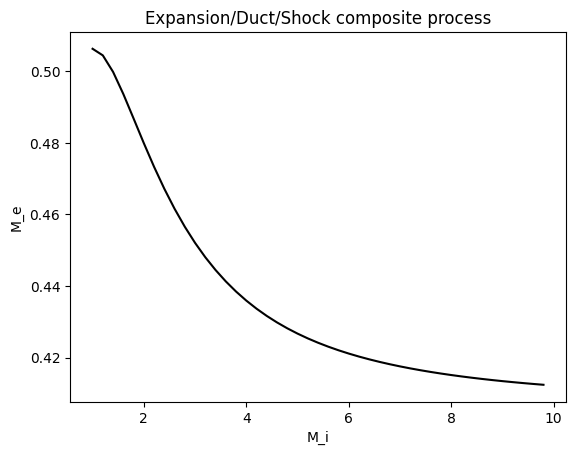

In [26]:
minlet = np.arange(1.0001, 10.0001, 0.2)  # range of Mach numbers
me = np.array([mexit(mi) for mi in minlet])
plt.plot(minlet, me, 'k-')
plt.title('Expansion/Duct/Shock composite process')
plt.xlabel('M_i')
plt.ylabel('M_e')


Note in the above, the array construct is used to vectorize the function mexit so that it can be evaluated for the range of mi values.  This voids having to write a loop.  Now, from the plot we see that there exists a Mi for which Me=0.44.  Let's find it and confirm it.

In [28]:
zfun = lambda mi: 0.44 - mexit(mi)
msolve = root_scalar(zfun, bracket=[1.0001, 10], method="brentq").root

print(msolve)

print(mexit(msolve))

3.6884786752186214
0.43999999999999995
